In [2]:
#ZARA DATASET

# IMPORTAR LIBRERIAS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import datetime
import seaborn as sns
from scipy import stats
from scipy.stats import spearmanr, pearsonr
import warnings
warnings.filterwarnings('ignore')
# Configuració estètica
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from scipy.stats import spearmanr, pearsonr, shapiro
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import shapiro
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
import numpy as np
# Configuración de estilo
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Librerías importadas correctamente")


# Si el archivo usa otro separador como punto y coma
df = pd.read_csv(
    r"C:\Users\Lucan Vieira\Documents\GitHub\Proyectos\Zara\Data\zara-dataset.csv",
    sep=';',  # o el delimitador que corresponda
    engine='python'
)

# Mostrar las primeras filas para verificar
print(df.head())

print("Tipos de datos por columna:")
print(df.dtypes) 
# Información detallada
print("\nInformación completa del dataset:")
print(df.info())

# Estadísticas descriptivas por tipo de dato
print("\nResumen de datos numéricos:")
print(df.describe())

print("\nFirst 5 rows:")
df.head()


✅ Librerías importadas correctamente
   Product ID Product Position Promotion Product Category Seasonal  \
0      185102            Aisle        No         Clothing       No   
1      188771            Aisle        No         Clothing       No   
2      180176          End-cap       Yes         Clothing      Yes   
3      112917            Aisle       Yes         Clothing      Yes   
4      192936          End-cap        No         Clothing      Yes   

   Sales Volume brand                                                url  \
0          2823  Zara  https://www.zara.com/us/en/basic-puffer-jacket...   
1           654  Zara  https://www.zara.com/us/en/tuxedo-jacket-p0889...   
2          2220  Zara  https://www.zara.com/us/en/slim-fit-suit-jacke...   
3          1568  Zara  https://www.zara.com/us/en/stretch-suit-jacket...   
4          2942  Zara  https://www.zara.com/us/en/double-faced-jacket...   

                sku                  name  \
0   272145190-250-2   BASIC PUFFER JACKE

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,sku,name,description,price,currency,scraped_at,terms,section
0,185102,Aisle,No,Clothing,No,2823,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,272145190-250-2,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,19.99,USD,2024-02-19T08:50:05.654618,jackets,MAN
1,188771,Aisle,No,Clothing,No,654,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,324052738-800-46,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,169.00,USD,2024-02-19T08:50:06.590930,jackets,MAN
2,180176,End-cap,Yes,Clothing,Yes,2220,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,335342680-800-44,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,129.00,USD,2024-02-19T08:50:07.301419,jackets,MAN
3,112917,Aisle,Yes,Clothing,Yes,1568,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,328303236-420-44,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,129.00,USD,2024-02-19T08:50:07.882922,jackets,MAN
4,192936,End-cap,No,Clothing,Yes,2942,Zara,https://www.zara.com/us/en/double-faced-jacket...,312368260-800-2,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,139.00,USD,2024-02-19T08:50:08.453847,jackets,MAN


In [3]:
def initial_data_assessment(df):
    """Comprehensive initial data assessment"""
    
    print("="*80)
    print("ZARA DATASET INITIAL ASSESSMENT")
    print("="*80)
    
    # Basic info
    print(f"\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    # Column info
    print("\n" + "="*80)
    print("COLUMN INFORMATION")
    print("="*80)
    
    column_info = []
    for col in df.columns:
        column_info.append({
            'Column': col,
            'Data Type': df[col].dtype,
            'Non-Null Count': df[col].count(),
            'Null Count': df[col].isnull().sum(),
            'Null %': f"{(df[col].isnull().sum() / len(df)) * 100:.2f}%",
            'Unique Values': df[col].nunique()
        })
    
    col_df = pd.DataFrame(column_info)
    print(col_df.to_string(index=False))
    
    return col_df

# Run initial assessment
col_info = initial_data_assessment(df)

ZARA DATASET INITIAL ASSESSMENT

Dataset Shape: 252 rows × 16 columns
Memory Usage: 0.26 MB

COLUMN INFORMATION
          Column Data Type  Non-Null Count  Null Count Null %  Unique Values
      Product ID     int64             252           0  0.00%            252
Product Position    object             252           0  0.00%              3
       Promotion    object             252           0  0.00%              2
Product Category    object             252           0  0.00%              1
        Seasonal    object             252           0  0.00%              2
    Sales Volume     int64             252           0  0.00%            234
           brand    object             252           0  0.00%              1
             url    object             252           0  0.00%            228
             sku    object             252           0  0.00%            228
            name    object             251           1  0.40%            194
     description    object             25

In [4]:
def clean_zara_data(df):
    """Systematic data cleaning for Zara dataset"""
    
    df_clean = df.copy()
    
    print("\n" + "="*80)
    print("DATA CLEANING PROCESS")
    print("="*80)
    
    # 1. Handle critical identifiers
    print("\n1. Handling Identifiers...")
    initial_rows = len(df_clean)
    
    # Remove rows without Product ID (critical for analysis)
    df_clean = df_clean.dropna(subset=['Product ID'])
    print(f"   - Removed {initial_rows - len(df_clean)} rows with missing Product ID")
    
    # Check for duplicate Product IDs
    duplicate_ids = df_clean['Product ID'].duplicated().sum()
    if duplicate_ids > 0:
        print(f"   - Found {duplicate_ids} duplicate Product IDs")
        # Keep first occurrence
        df_clean = df_clean.drop_duplicates(subset=['Product ID'], keep='first')
        print(f"   - Removed duplicates, {len(df_clean)} unique products remaining")
    
    # 2. Handle price data (critical for analysis)
    print("\n2. Cleaning Price Data...")
    
    # Convert price to numeric
    if 'price' in df_clean.columns:
        # Check if price contains currency symbols
        sample_prices = df_clean['price'].astype(str).head(10)
        if any(char in ' '.join(sample_prices) for char in ['€', '$', '£']):
            df_clean['price'] = df_clean['price'].astype(str).str.replace('€', '')
            df_clean['price'] = df_clean['price'].astype(str).str.replace('$', '')
            df_clean['price'] = df_clean['price'].astype(str).str.replace('£', '')
            df_clean['price'] = df_clean['price'].astype(str).str.replace(',', '')
            print("   - Removed currency symbols from price column")
        
        df_clean['price'] = pd.to_numeric(df_clean['price'], errors='coerce')
        
        # Remove unrealistic prices (outliers)
        price_outliers = df_clean[df_clean['price'] <= 0].shape[0]
        if price_outliers > 0:
            df_clean = df_clean[df_clean['price'] > 0]
            print(f"   - Removed {price_outliers} rows with invalid prices (≤ 0)")
        
        # Handle missing prices
        missing_price = df_clean['price'].isnull().sum()
        if missing_price > 0:
            median_price = df_clean['price'].median()
            df_clean['price'] = df_clean['price'].fillna(median_price)
            print(f"   - Filled {missing_price} missing prices with median: {median_price:.2f}")
    
    # 3. Handle sales volume
    print("\n3. Cleaning Sales Volume Data...")
    if 'Sales Volume' in df_clean.columns:
        # Convert to numeric
        df_clean['Sales Volume'] = pd.to_numeric(df_clean['Sales Volume'], errors='coerce')
        
        # Handle negative sales (shouldn't exist, but check)
        negative_sales = (df_clean['Sales Volume'] < 0).sum()
        if negative_sales > 0:
            df_clean.loc[df_clean['Sales Volume'] < 0, 'Sales Volume'] = 0
            print(f"   - Converted {negative_sales} negative sales volumes to 0")
        
        # Fill missing sales with 0 (assuming no sales)
        missing_sales = df_clean['Sales Volume'].isnull().sum()
        if missing_sales > 0:
            df_clean['Sales Volume'] = df_clean['Sales Volume'].fillna(0)
            print(f"   - Filled {missing_sales} missing sales with 0")
    
    # 4. Handle categorical variables
    print("\n4. Cleaning Categorical Variables...")
    
    categorical_cols = ['Promotion', 'Seasonal', 'brand', 'section', 'Product Category']
    for col in categorical_cols:
        if col in df_clean.columns:
            missing = df_clean[col].isnull().sum()
            if missing > 0:
                df_clean[col] = df_clean[col].fillna('Unknown')
                print(f"   - {col}: filled {missing} missing values with 'Unknown'")
            
            # Standardize string formatting
            df_clean[col] = df_clean[col].astype(str).str.strip().str.title()
    
    # 5. Handle text columns
    print("\n5. Cleaning Text Columns...")
    text_cols = ['name', 'description', 'sku', 'terms']
    for col in text_cols:
        if col in df_clean.columns:
            missing = df_clean[col].isnull().sum()
            if missing > 0:
                df_clean[col] = df_clean[col].fillna('')
                print(f"   - {col}: filled {missing} missing values with empty string")
            
            # Clean whitespace
            df_clean[col] = df_clean[col].astype(str).str.strip()
    
    # 6. Handle datetime
    print("\n6. Processing Temporal Data...")
    if 'scraped_at' in df_clean.columns:
        df_clean['scraped_at'] = pd.to_datetime(df_clean['scraped_at'], errors='coerce')
        
        # Extract useful time features
        df_clean['scrape_date'] = df_clean['scraped_at'].dt.date
        df_clean['scrape_month'] = df_clean['scraped_at'].dt.month
        df_clean['scrape_day_of_week'] = df_clean['scraped_at'].dt.dayofweek
        
        missing_date = df_clean['scraped_at'].isnull().sum()
        if missing_date > 0:
            print(f"   - Warning: {missing_date} rows have invalid scrape dates")
    
    # 7. Handle Product Position (numeric)
    print("\n7. Processing Product Position...")
    if 'Product Position' in df_clean.columns:
        df_clean['Product Position'] = pd.to_numeric(df_clean['Product Position'], errors='coerce')
        
        # Fill missing with median
        missing_pos = df_clean['Product Position'].isnull().sum()
        if missing_pos > 0:
            median_pos = df_clean['Product Position'].median()
            df_clean['Product Position'] = df_clean['Product Position'].fillna(median_pos)
            print(f"   - Filled {missing_pos} missing positions with median: {median_pos:.0f}")
    
    # 8. Create derived features
    print("\n8. Creating Derived Features...")
    
    # Price categories
    if 'price' in df_clean.columns:
        df_clean['price_category'] = pd.cut(df_clean['price'], 
                                           bins=[0, 25, 50, 100, 250, float('inf')],
                                           labels=['Budget', 'Affordable', 'Mid-Range', 'Premium', 'Luxury'])
        print("   - Created price_category (Budget, Affordable, Mid-Range, Premium, Luxury)")
    
    # Sales performance tier
    if 'Sales Volume' in df_clean.columns:
        df_clean['sales_tier'] = pd.qcut(df_clean['Sales Volume'].clip(lower=0), 
                                         q=4, 
                                         labels=['Low', 'Medium-Low', 'Medium-High', 'High'],
                                         duplicates='drop')
        print("   - Created sales_tier (Low, Medium-Low, Medium-High, High)")
    
    # Combined feature: Revenue
    if 'price' in df_clean.columns and 'Sales Volume' in df_clean.columns:
        df_clean['revenue'] = df_clean['price'] * df_clean['Sales Volume']
        print("   - Created revenue (price × sales volume)")
    
    print("\n" + "="*80)
    print(f"CLEANING COMPLETE: {len(df_clean)} rows remaining ({initial_rows - len(df_clean)} rows removed)")
    print("="*80)
    
    return df_clean

# Apply cleaning
df_clean = clean_zara_data(df)


DATA CLEANING PROCESS

1. Handling Identifiers...
   - Removed 0 rows with missing Product ID

2. Cleaning Price Data...

3. Cleaning Sales Volume Data...

4. Cleaning Categorical Variables...

5. Cleaning Text Columns...
   - name: filled 1 missing values with empty string
   - description: filled 2 missing values with empty string

6. Processing Temporal Data...

7. Processing Product Position...
   - Filled 252 missing positions with median: nan

8. Creating Derived Features...
   - Created price_category (Budget, Affordable, Mid-Range, Premium, Luxury)
   - Created sales_tier (Low, Medium-Low, Medium-High, High)
   - Created revenue (price × sales volume)

CLEANING COMPLETE: 252 rows remaining (0 rows removed)



EXPLORATORY DATA ANALYSIS

1. SALES OVERVIEW
----------------------------------------
Total Products: 252
Total Sales Volume: 459,573 units
Total Revenue: $38,988,476.48
Average Price: $86.25
Median Price: $79.90
Average Sales per Product: 1823.70 units
Average Revenue per Product: $154716.18


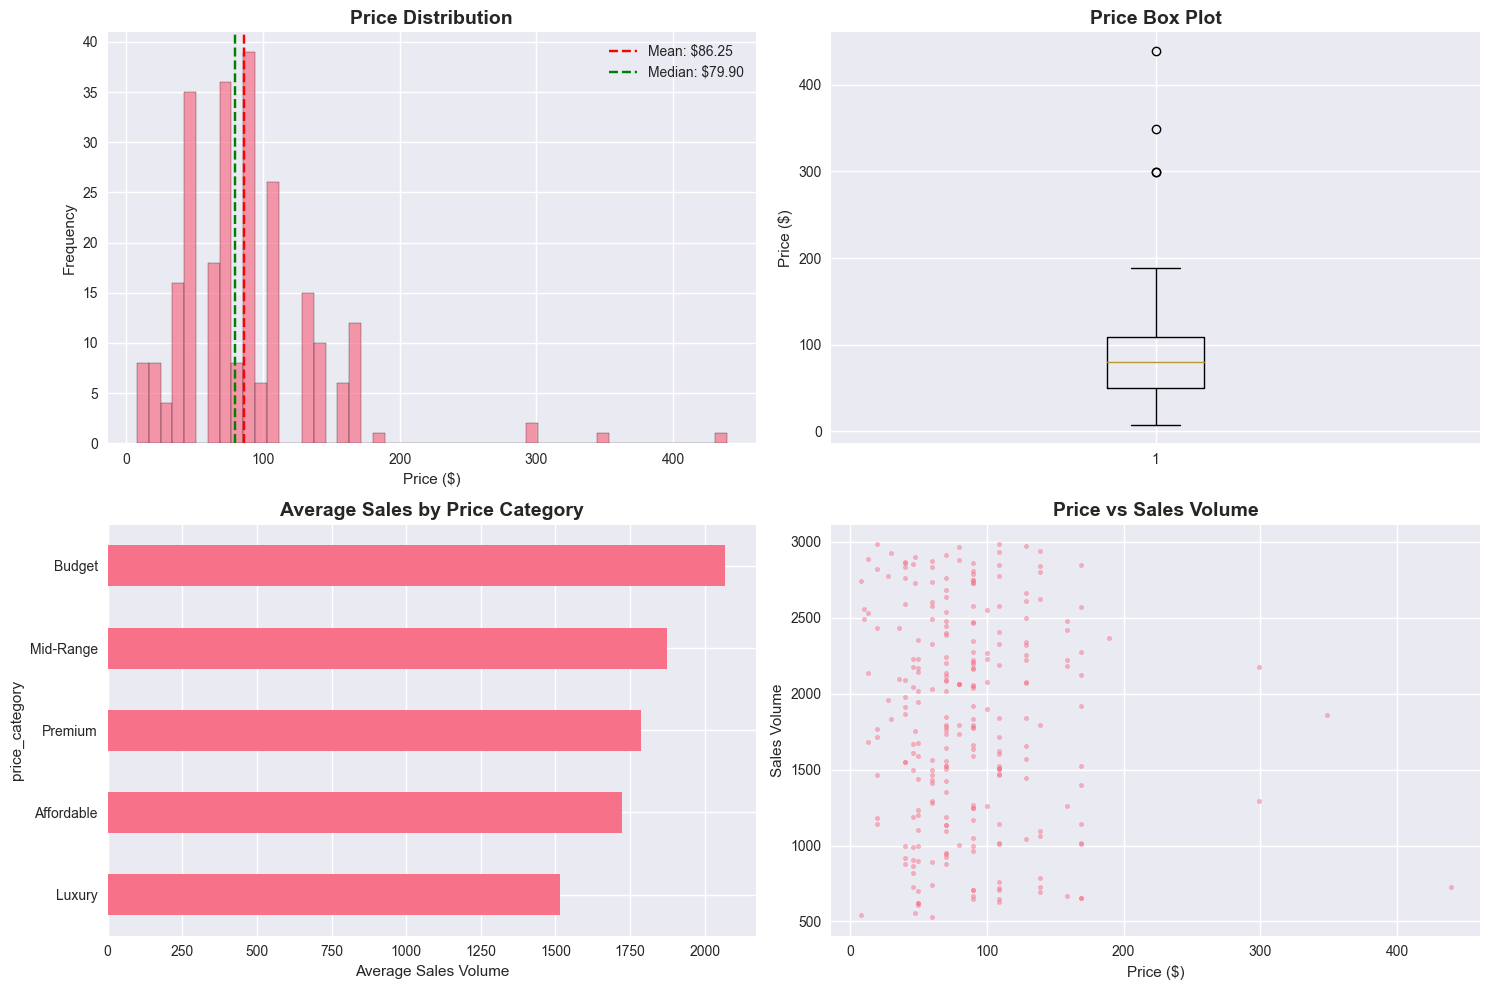

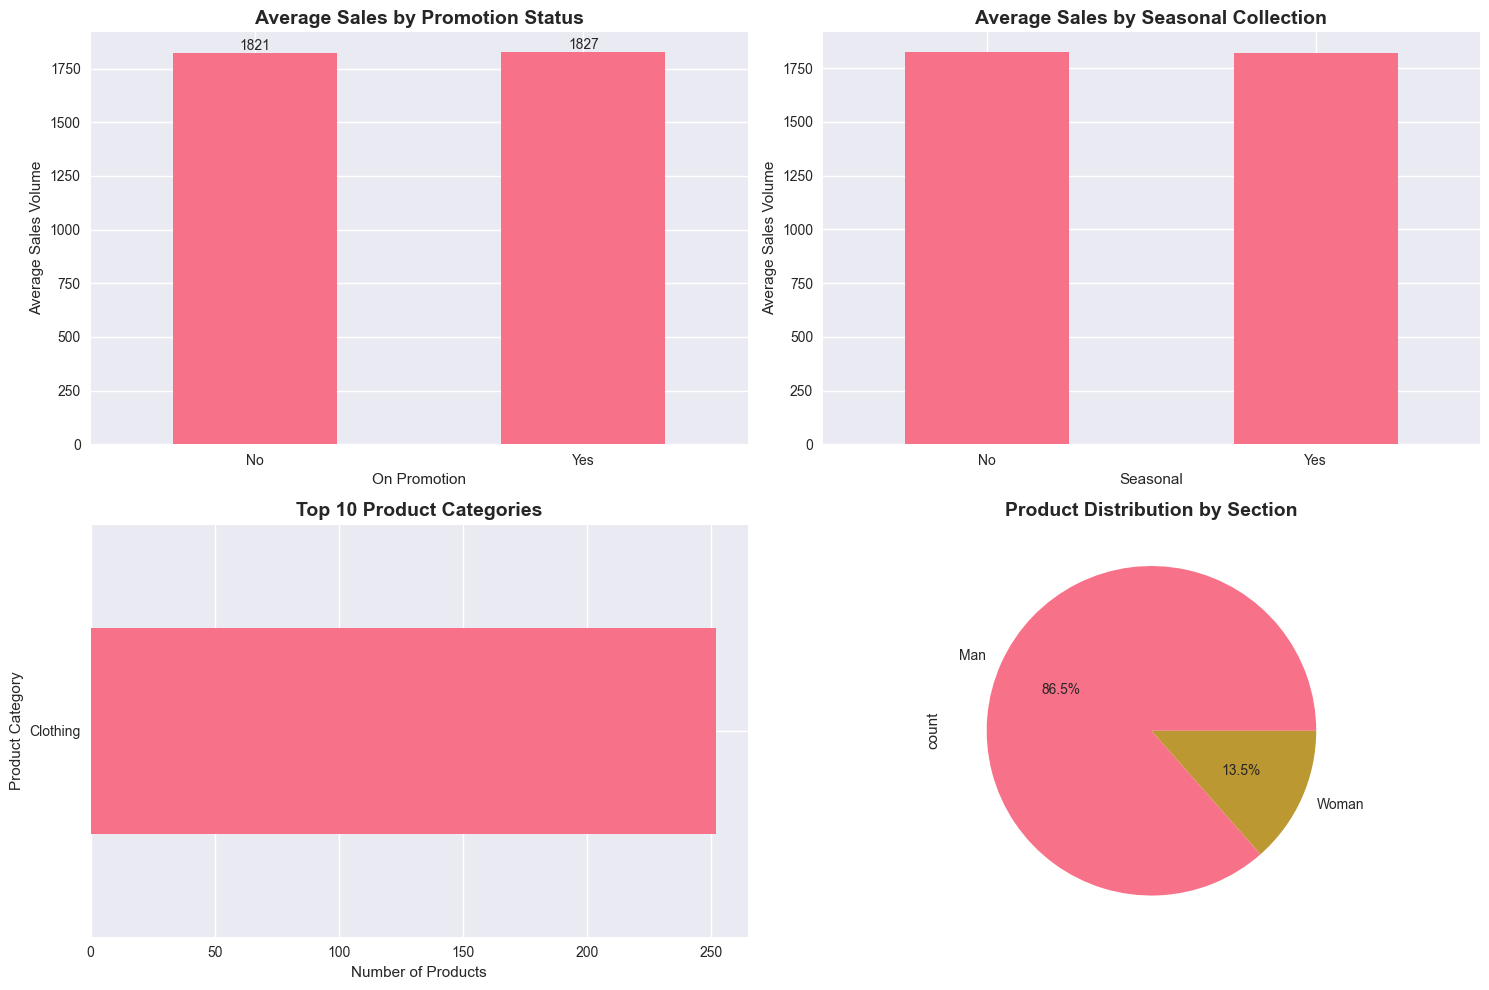

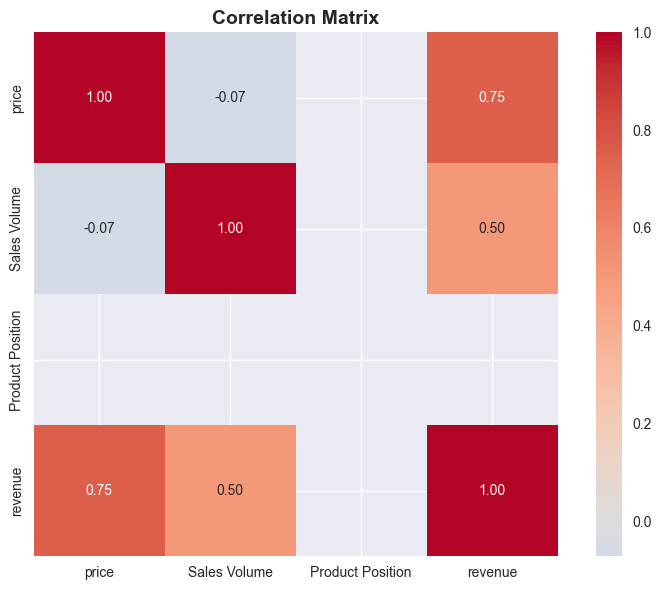

In [5]:
def perform_eda(df):
    """Comprehensive exploratory data analysis"""
    
    print("\n" + "="*80)
    print("EXPLORATORY DATA ANALYSIS")
    print("="*80)
    
    # 1. Sales Overview
    print("\n1. SALES OVERVIEW")
    print("-"*40)
    print(f"Total Products: {len(df):,}")
    print(f"Total Sales Volume: {df['Sales Volume'].sum():,.0f} units")
    print(f"Total Revenue: ${df['revenue'].sum():,.2f}")
    print(f"Average Price: ${df['price'].mean():.2f}")
    print(f"Median Price: ${df['price'].median():.2f}")
    print(f"Average Sales per Product: {df['Sales Volume'].mean():.2f} units")
    print(f"Average Revenue per Product: ${df['revenue'].mean():.2f}")
    
    # 2. Price Distribution Analysis
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Price histogram
    axes[0, 0].hist(df['price'], bins=50, edgecolor='black', alpha=0.7)
    axes[0, 0].set_title('Price Distribution', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Price ($)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].axvline(df['price'].mean(), color='red', linestyle='--', label=f'Mean: ${df["price"].mean():.2f}')
    axes[0, 0].axvline(df['price'].median(), color='green', linestyle='--', label=f'Median: ${df["price"].median():.2f}')
    axes[0, 0].legend()
    
    # Box plot
    axes[0, 1].boxplot(df['price'])
    axes[0, 1].set_title('Price Box Plot', fontsize=14, fontweight='bold')
    axes[0, 1].set_ylabel('Price ($)')
    
    # Price by category
    if 'price_category' in df.columns:
        price_cat_sales = df.groupby('price_category')['Sales Volume'].mean().sort_values()
        price_cat_sales.plot(kind='barh', ax=axes[1, 0])
        axes[1, 0].set_title('Average Sales by Price Category', fontsize=14, fontweight='bold')
        axes[1, 0].set_xlabel('Average Sales Volume')
    
    # Price vs Sales scatter
    axes[1, 1].scatter(df['price'], df['Sales Volume'], alpha=0.5, s=10)
    axes[1, 1].set_title('Price vs Sales Volume', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Price ($)')
    axes[1, 1].set_ylabel('Sales Volume')
    
    plt.tight_layout()
    plt.show()
    
    # 3. Categorical Analysis
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Promotion impact
    if 'Promotion' in df.columns:
        promo_sales = df.groupby('Promotion')['Sales Volume'].mean()
        promo_sales.plot(kind='bar', ax=axes[0, 0])
        axes[0, 0].set_title('Average Sales by Promotion Status', fontsize=14, fontweight='bold')
        axes[0, 0].set_xlabel('On Promotion')
        axes[0, 0].set_ylabel('Average Sales Volume')
        axes[0, 0].tick_params(axis='x', rotation=0)
        
        # Add value labels
        for i, v in enumerate(promo_sales):
            axes[0, 0].text(i, v, f'{v:.0f}', ha='center', va='bottom')
    
    # Seasonal impact
    if 'Seasonal' in df.columns:
        seasonal_sales = df.groupby('Seasonal')['Sales Volume'].mean()
        seasonal_sales.plot(kind='bar', ax=axes[0, 1])
        axes[0, 1].set_title('Average Sales by Seasonal Collection', fontsize=14, fontweight='bold')
        axes[0, 1].set_xlabel('Seasonal')
        axes[0, 1].set_ylabel('Average Sales Volume')
        axes[0, 1].tick_params(axis='x', rotation=0)
    
    # Top categories
    if 'Product Category' in df.columns:
        top_categories = df['Product Category'].value_counts().head(10)
        top_categories.plot(kind='barh', ax=axes[1, 0])
        axes[1, 0].set_title('Top 10 Product Categories', fontsize=14, fontweight='bold')
        axes[1, 0].set_xlabel('Number of Products')
    
    # Sections distribution
    if 'section' in df.columns:
        section_counts = df['section'].value_counts().head(10)
        section_counts.plot(kind='pie', ax=axes[1, 1], autopct='%1.1f%%')
        axes[1, 1].set_title('Product Distribution by Section', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # 4. Correlation Analysis
    numeric_cols = ['price', 'Sales Volume', 'Product Position', 'revenue']
    available_numeric = [col for col in numeric_cols if col in df.columns]
    
    if len(available_numeric) > 1:
        corr_matrix = df[available_numeric].corr()
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
        plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    
 
# Run EDA
perform_eda(df_clean)

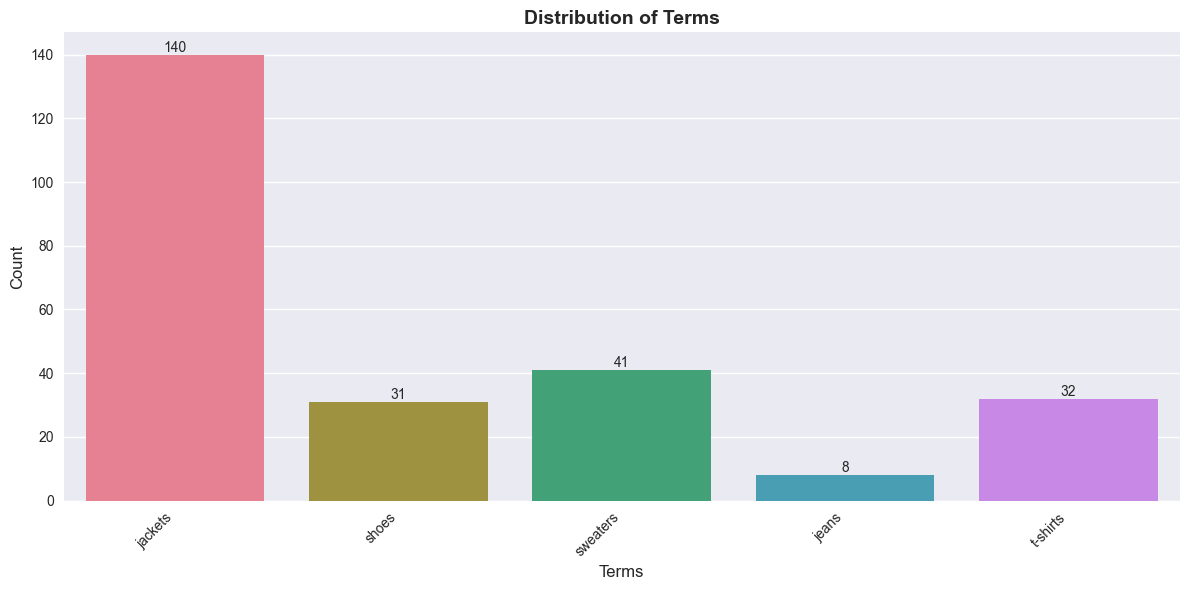

In [6]:
# Create a gradient color palette
colors = sns.color_palette("husl", n_colors=df['terms'].nunique())

plt.figure(figsize=(12, 6))

# Apply the colors
ax = sns.countplot(x='terms', data=df, palette=colors)

plt.title('Distribution of Terms', fontsize=14, fontweight='bold')
plt.xlabel('Terms', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add value labels
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Numeric columns: ['Product ID', 'Sales Volume', 'price']


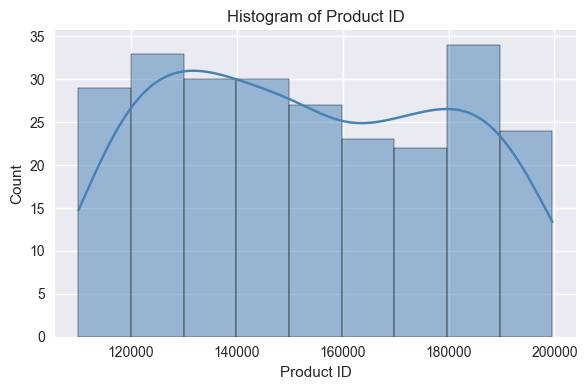

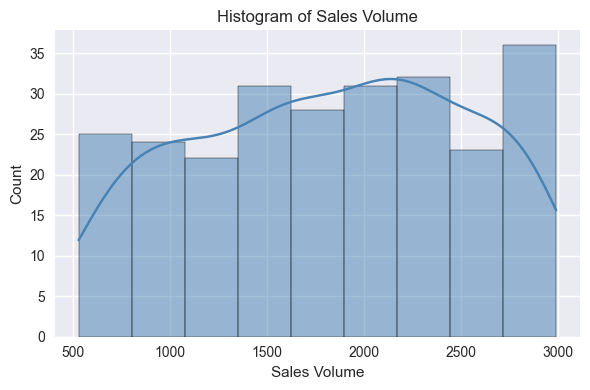

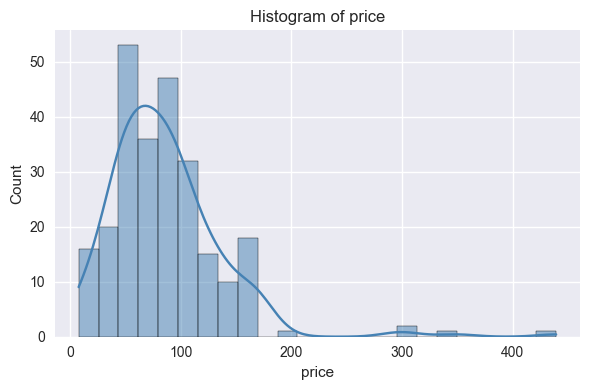

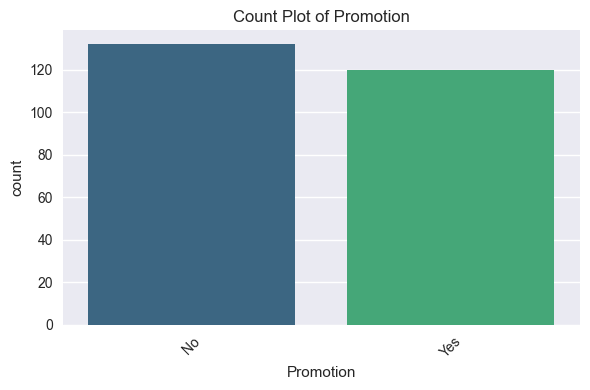

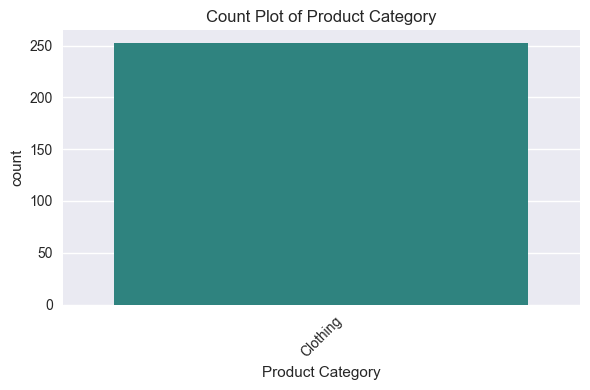

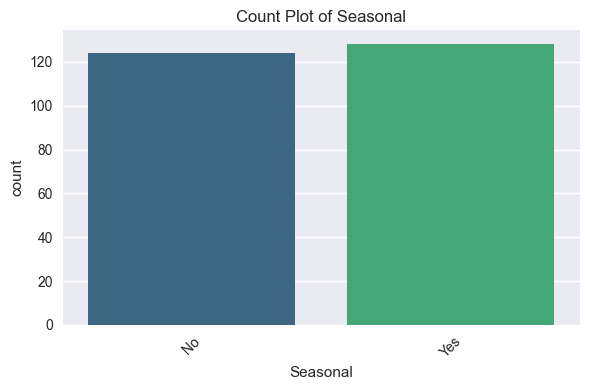

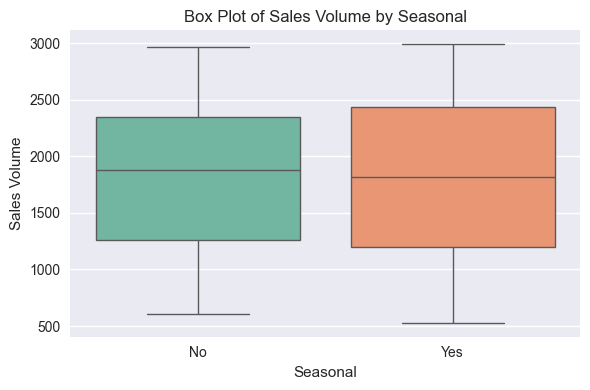

In [7]:
# List of numeric columns
numeric_df = df.select_dtypes(include=[np.number])
print('Numeric columns:', numeric_df.columns.tolist())

# Histogram visualizations for numeric columns
for col in numeric_df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(numeric_df[col], kde=True, color='steelblue')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

# Count plots for some selected categorical columns
categorical_cols = ['Promotion', 'Product Category', 'Seasonal']
for col in categorical_cols:
    if col in df.columns:
        plt.figure(figsize=(6,4))
        sns.countplot(data=df, x=col, palette='viridis')
        plt.title(f'Count Plot of {col}')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

# Box plot for Sales Volume grouped by Seasonal
if 'Seasonal' in df.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x='Seasonal', y='Sales Volume', palette='Set2')
    plt.title('Box Plot of Sales Volume by Seasonal')
    plt.tight_layout()
    plt.show()

In [8]:
def generate_business_insights(df):
    """Generate key business insights for portfolio"""
    
    print("\n" + "="*80)
    print("KEY BUSINESS INSIGHTS")
    print("="*80)
    
    insights = {}
    
    # 1. Promotion Effectiveness
    if 'Promotion' in df.columns:
        # Filter for valid promotion values only
        valid_promo = df[df['Promotion'].isin(['Yes', 'No', 'True', 'False', True, False])]
        
        if len(valid_promo) > 0:
            # Standardize promotion values
            valid_promo.loc[:, 'Promotion'] = valid_promo['Promotion'].astype(str).str.lower()
            valid_promo.loc[:, 'Promotion'] = valid_promo['Promotion'].map({'yes': 'Yes', 'true': 'Yes', 
                                                                            'no': 'No', 'false': 'No'})
            
            promo_effect = valid_promo.groupby('Promotion')['Sales Volume'].agg(['mean', 'median', 'count'])
            
            if 'Yes' in promo_effect.index and 'No' in promo_effect.index:
                lift_percentage = ((promo_effect.loc['Yes', 'mean'] - promo_effect.loc['No', 'mean']) / 
                                   promo_effect.loc['No', 'mean']) * 100
                
                print("\n📊 PROMOTION EFFECTIVENESS:")
                print(f"   - Products on promotion sell {lift_percentage:.1f}% more units on average")
                print(f"   - Average sales with promotion: {promo_effect.loc['Yes', 'mean']:.0f} units")
                print(f"   - Average sales without promotion: {promo_effect.loc['No', 'mean']:.0f} units")
                print(f"   - Number of products on promotion: {promo_effect.loc['Yes', 'count']:.0f}")
                print(f"   - Number of products not on promotion: {promo_effect.loc['No', 'count']:.0f}")
                
                insights['promotion_lift'] = lift_percentage
                insights['promotion_analysis'] = promo_effect.to_dict()
            else:
                print("\n📊 PROMOTION EFFECTIVENESS:")
                print(f"   - Promotion values found: {promo_effect.index.tolist()}")
                print(f"   - Promotion analysis skipped - need 'Yes' and 'No' values")
        else:
            print("\n📊 PROMOTION EFFECTIVENESS:")
            print("   - No valid promotion data found")
    
    # 2. Seasonal Products Performance
    if 'Seasonal' in df.columns:
        # Filter for valid seasonal values
        valid_seasonal = df[df['Seasonal'].isin(['Yes', 'No', 'True', 'False', True, False])]
        
        if len(valid_seasonal) > 0:
            valid_seasonal.loc[:, 'Seasonal'] = valid_seasonal['Seasonal'].astype(str).str.lower()
            valid_seasonal.loc[:, 'Seasonal'] = valid_seasonal['Seasonal'].map({'yes': 'Yes', 'true': 'Yes',
                                                                                'no': 'No', 'false': 'No'})
            
            seasonal_effect = valid_seasonal.groupby('Seasonal')['Sales Volume'].mean()
            
            print("\n🌸 SEASONAL PRODUCTS:")
            if 'Yes' in seasonal_effect.index and 'No' in seasonal_effect.index:
                print(f"   - Seasonal products sell {seasonal_effect['Yes']:.0f} units on average")
                print(f"   - Non-seasonal products sell {seasonal_effect['No']:.0f} units on average")
                outperformance = ((seasonal_effect['Yes'] - seasonal_effect['No']) / seasonal_effect['No'] * 100)
                print(f"   - Seasonal products outperform by {outperformance:.1f}%")
                
                insights['seasonal_performance'] = seasonal_effect.to_dict()
            else:
                print(f"   - Seasonal values found: {seasonal_effect.index.tolist()}")
    
    # 3. Price Sensitivity
    if 'price_category' in df.columns and 'Sales Volume' in df.columns:
        price_performance = df.groupby('price_category')['Sales Volume'].agg(['mean', 'count']).sort_values('mean', ascending=False)
        
        print("\n💰 PRICE SENSITIVITY:")
        for category, row in price_performance.iterrows():
            print(f"   - {category}: {row['mean']:.0f} units average sales ({row['count']} products)")
        
        insights['price_performance'] = price_performance.to_dict()
    
    # 4. Best Performing Categories
    if 'Product Category' in df.columns and 'Sales Volume' in df.columns:
        # Filter out 'Unknown' category if it exists
        category_analysis = df[df['Product Category'] != 'Unknown'] if 'Product Category' in df.columns else df
        
        top_categories_by_sales = category_analysis.groupby('Product Category')['Sales Volume'].sum().sort_values(ascending=False).head(5)
        top_categories_by_avg = category_analysis.groupby('Product Category')['Sales Volume'].mean().sort_values(ascending=False).head(5)
        
        print("\n🏆 TOP 5 PRODUCT CATEGORIES BY TOTAL SALES:")
        for category, sales in top_categories_by_sales.items():
            print(f"   - {category}: {sales:,.0f} units")
        
        print("\n📈 TOP 5 PRODUCT CATEGORIES BY AVERAGE SALES:")
        for category, sales in top_categories_by_avg.items():
            print(f"   - {category}: {sales:.0f} units average")
        
        insights['top_categories_by_total'] = top_categories_by_sales.to_dict()
        insights['top_categories_by_avg'] = top_categories_by_avg.to_dict()
    
    # 5. Revenue Drivers
    if 'revenue' in df.columns and 'Product Category' in df.columns:
        top_revenue = df.groupby('Product Category')['revenue'].sum().sort_values(ascending=False).head(5)
        
        print("\n💵 TOP 5 REVENUE GENERATORS:")
        for category, revenue in top_revenue.items():
            print(f"   - {category}: ${revenue:,.2f}")
        
        insights['top_revenue_categories'] = top_revenue.to_dict()
    
    # 6. Section Analysis
    if 'section' in df.columns and 'Sales Volume' in df.columns:
        # Filter out 'Unknown' section
        section_data = df[df['section'] != 'Unknown'] if 'section' in df.columns else df
        
        section_performance = section_data.groupby('section')['Sales Volume'].agg(['mean', 'count']).sort_values('mean', ascending=False)
        
        print("\n👥 SECTION PERFORMANCE:")
        for section, row in section_performance.head(3).iterrows():
            print(f"   - {section}: {row['mean']:.0f} units average sales ({row['count']} products)")
        
        insights['top_sections'] = section_performance.head(3).to_dict()
    
    # 7. Catalog Position Impact
    if 'Product Position' in df.columns and 'Sales Volume' in df.columns:
        # Calculate correlation only with valid numeric data
        position_data = df[['Product Position', 'Sales Volume']].dropna()
        
        if len(position_data) > 1:
            position_corr = position_data.corr().iloc[0, 1]
            
            print(f"\n📍 CATALOG POSITION IMPACT:")
            print(f"   - Correlation between position and sales: {position_corr:.2f}")
            if position_corr > 0.1:
                print(f"   - Products placed later in catalog tend to sell more (weak positive correlation)")
            elif position_corr < -0.1:
                print(f"   - Products placed earlier in catalog tend to sell more (weak negative correlation)")
            else:
                print(f"   - No significant correlation between position and sales")
            
            insights['position_correlation'] = position_corr
    
    # 8. Additional Insights - Price Distribution
    if 'price' in df.columns:
        print("\n💲 PRICE ANALYSIS:")
        print(f"   - Average price: ${df['price'].mean():.2f}")
        print(f"   - Median price: ${df['price'].median():.2f}")
        print(f"   - Price range: ${df['price'].min():.2f} - ${df['price'].max():.2f}")
        
        # Identify price outliers using IQR
        Q1 = df['price'].quantile(0.25)
        Q3 = df['price'].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df[(df['price'] < (Q1 - 1.5 * IQR)) | (df['price'] > (Q3 + 1.5 * IQR))]
        
        if len(outliers) > 0:
            print(f"   - Found {len(outliers)} price outliers ({len(outliers)/len(df)*100:.1f}% of products)")
    
    # 9. Missing Data Summary
    print("\n📊 DATA QUALITY:")
    missing_data = df.isnull().sum()
    missing_percentage = (missing_data / len(df)) * 100
    missing_summary = missing_data[missing_data > 0]
    
    if len(missing_summary) > 0:
        print("   - Missing values after cleaning:")
        for col, count in missing_summary.items():
            print(f"     • {col}: {count} ({missing_percentage[col]:.1f}%)")
    else:
        print("   - No missing values remaining in dataset")
    
    print(f"\n   - Total products analyzed: {len(df):,}")
    print(f"   - Total sales volume: {df['Sales Volume'].sum():,.0f} units")
    print(f"   - Total revenue: ${df['revenue'].sum():,.2f}" if 'revenue' in df.columns else "")
    
    return insights

# Generate insights with the fixed function
insights = generate_business_insights(df_clean)


KEY BUSINESS INSIGHTS

📊 PROMOTION EFFECTIVENESS:
   - Products on promotion sell 0.4% more units on average
   - Average sales with promotion: 1827 units
   - Average sales without promotion: 1821 units
   - Number of products on promotion: 120
   - Number of products not on promotion: 132

🌸 SEASONAL PRODUCTS:
   - Seasonal products sell 1822 units on average
   - Non-seasonal products sell 1826 units on average
   - Seasonal products outperform by -0.2%

💰 PRICE SENSITIVITY:
   - Budget: 2069 units average sales (16.0 products)
   - Mid-Range: 1874 units average sales (107.0 products)
   - Premium: 1787 units average sales (70.0 products)
   - Affordable: 1723 units average sales (55.0 products)
   - Luxury: 1514 units average sales (4.0 products)

🏆 TOP 5 PRODUCT CATEGORIES BY TOTAL SALES:
   - Clothing: 459,573 units

📈 TOP 5 PRODUCT CATEGORIES BY AVERAGE SALES:
   - Clothing: 1824 units average

💵 TOP 5 REVENUE GENERATORS:
   - Clothing: $38,988,476.48

👥 SECTION PERFORMANCE:
  

                This project provided valuable insights into Zara's sales performance. By analyzing sales trends, purchase patterns, and model predictions, we were able to make recommendations for optimizing inventory, improving marketing strategies, and enhancing profitability. Further analysis could include studying the impact of promotions, price adjustments, and other external factors on sales performance.We performed a detailed analysis of the Zara sales dataset to uncover insights into the company's sales performance, customer purchase patterns, and overall trends.By continuously refining these models and incorporating additional data sources, Zara can enhance its operational efficiency and increase profitability.This project provides Zara with actionable insights into its sales patterns and performance. 